In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# benchmarking 

# load data
sarand_ww = pd.read_csv('/home/david/dm-lab/subgraphia_analyses/fai_correctness/sarand_ww_SR_fai_out.tsv', sep='\t')
subgraphia_ww = pd.read_csv('/home/david/dm-lab/subgraphia_analyses/fai_correctness/ww_SR_fai_out.tsv', sep='\t')

#add a column for dataset
sarand_ww['Dataset'] = 'Sarand 38%'
subgraphia_ww['Dataset'] = 'SubGraphia'

# combine dataframes
combined_ww = pd.concat([sarand_ww, subgraphia_ww], ignore_index=True)

# for instances where there are duplicate "queried_path" entries, take the higher "proportion-query-genes-found" value
combined_ww = combined_ww.sort_values(by='proportion-query-genes-found', ascending=False).drop_duplicates(subset='queried_path', keep='first')

# print median proportion-query-genes-found for each dataset
median_proportion_query_genes_found_by_dataset = combined_ww.groupby('Dataset')['proportion-query-genes-found'].median()

# get hexcode for 4th colour in Dark2 pallette
from matplotlib import cm
from matplotlib.colors import to_hex
cmap = cm.get_cmap('Dark2')
color = cmap(3)  # Get the RGBA values for the 4th color
hex_color = to_hex(color)  # Convert RGBA to hex

pallette_benchmark = [hex_color, '#006633', '#D95F02']  
tool_palette = ['#007bb4ff','#1B9E77FF', '#D95F02FF']

# plot proportion-query-genes-found as a boxplot
# add a dataset called "Argcontextprofiler" with null values for proportion-query-genes-found
argcontextprofiler_ww = pd.DataFrame({'Dataset': ['Argcontextprofiler DNF'], 'proportion-query-genes-found': [None]})
combined_ww = pd.concat([combined_ww, argcontextprofiler_ww], ignore_index=True)
#increase font size
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 6))
sns.boxplot(x='Dataset', y='proportion-query-genes-found', data=combined_ww, palette=pallette_benchmark)
plt.xlabel('')
plt.ylabel('Proportion of Ground Truth Genes Found')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('proportion_query_genes_found_benchmarking_boxplot_ww.png', dpi=300)


# length dist figure 
subgraphia_ww_length = pd.read_csv('/data/raid1_HDD/David/subgraph_analyser_runs/ww_SR_results/metadata.tsv', sep='\t')
subgraphia_ww_length['Dataset'] = 'SubGraphia'
sarand_ww_length = pd.read_csv('/home/david/dm-lab/subgraphia_analyses/benchmark/sarand/results_05-06/final_result/all_paths/lengths.tsv', sep='\t', header=None, names=['path', 'length'])
sarand_ww_length['Dataset'] = 'Sarand 38% complete'

def summarize_metadata(df):
    summarized = df.groupby(['ARO', 'tax_ID_names'], dropna=False).agg({
        'path_length': 'median',
        'Dataset': 'first',  # Keep the dataset name for each group
        'path_id': 'first'  # Keep the path_id for each group
    }).reset_index()
    return summarized
subgraphia_ww_length = summarize_metadata(subgraphia_ww_length)

# keep only the "length" and "Dataset" columns
subgraphia_ww_length = subgraphia_ww_length[['path_length', 'Dataset']]
# rename "path_length" column to "length"
subgraphia_ww_length = subgraphia_ww_length.rename(columns={'path_length': 'length'})
sarand_ww_length = sarand_ww_length[['length', 'Dataset']]

# combine dataframes
combined_length = pd.concat([subgraphia_ww_length, sarand_ww_length], ignore_index=True)

# filter out lengths greater than 200000
combined_length = combined_length[combined_length['length'] <= 100000]

# plot length as a kdeplot, log scale the x axis, add Argcontextprofiler DNF as a dataset with null values for length
argcontextprofiler_length = pd.DataFrame({'Dataset': ['Argcontextprofiler DNF'], 'length': [None]})
combined_length = pd.concat([combined_length, argcontextprofiler_length], ignore_index=True)
plt.figure(figsize=(8, 6))
sns.kdeplot(data=combined_length, x='length', hue='Dataset', common_norm=False, palette=tool_palette, linewidth=4)
plt.xlabel('Path Length')
plt.ylabel('Density')
plt.tight_layout()

## runtimes

Tool = ['SubGraphia','Sarand 38%', 'Argcontextprofiler DNF']
runtimes = [3.43, 162.53, 1.89]

runtime_df = pd.DataFrame({'Tool': Tool, 'Runtime (hours)': runtimes})

# plot runtimes as a barplot
plt.figure(figsize=(8, 6))
sns.barplot(x='Tool', y='Runtime (hours)', data=runtime_df, palette=tool_palette)
# add bar labels with ">" on Sarand 38% complete and Argcontextprofiler DNF
for index, row in runtime_df.iterrows():
    if row['Tool'] == 'Sarand 38%' or row['Tool'] == 'Argcontextprofiler DNF':
        plt.text(index, row['Runtime (hours)'] + 1.5, f">{row['Runtime (hours)']:.2f}", ha='center', va='bottom')
    else:
        plt.text(index, row['Runtime (hours)'] + 1.5, f"{row['Runtime (hours)']:.2f}", ha='center', va='bottom')
plt.xlabel('')
plt.ylabel('Runtime (hours)')
plt.tight_layout()

# memory 
subG_trace = pd.read_csv('~/dm-lab/public_repos/SubGraphia/subgraphia/benchmark_ww_results/trace.tsv', sep='\t')

peak_RSS_subg = subG_trace['peak_rss'].max() / (1024 * 1024 * 1024)  # convert from bytes to GB

print(f"Peak RSS for SubGraphia: {peak_RSS_subg:.2f} GB")
print(subG_trace['peak_rss'].max())

mem = [peak_RSS_subg, 141.8, 425]
mem_df = pd.DataFrame({'Tool': Tool, 'Memory (GB)': mem})

# plot memory as a barplot
plt.figure(figsize=(8, 6))
sns.barplot(x='Tool', y='Memory (GB)', data=mem_df, palette=tool_palette)
# add bar labels with ">" on Argcontextprofiler DNF
for index, row in mem_df.iterrows():
    if row['Tool'] == 'Argcontextprofiler DNF':
        plt.text(index, row['Memory (GB)'] + 5, f">{row['Memory (GB)']:.2f}", ha='center', va='bottom')
    else:
        plt.text(index, row['Memory (GB)'] + 5, f"{row['Memory (GB)']:.2f}", ha='center', va='bottom')
plt.xlabel('')
plt.ylabel('Memory (GB)')
plt.tight_layout()

# create a four panel figure with proportion-query-genes-found, length, runtime and memory, label with A, B, C, D in the top left corner of each panel, and save as a png
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
# add labels to each panel
axs[0, 0].text(-0.1, 1.1, 'A', transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')
axs[0, 1].text(-0.1, 1.1, 'B', transform=axs[0, 1].transAxes, fontsize=16, fontweight='bold')
axs[1, 0].text(-0.1, 1.1, 'C', transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')
axs[1, 1].text(-0.1, 1.1, 'D', transform=axs[1, 1].transAxes, fontsize=16, fontweight='bold')
sns.boxplot(x='Dataset', y='proportion-query-genes-found', data=combined_ww, palette=tool_palette, ax=axs[0, 0])
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_ylabel('Proportion of Ground Truth Genes Found')
sns.kdeplot(data=combined_length, x='length', hue='Dataset', common_norm=False, palette=tool_palette, linewidth=4, ax=axs[0, 1])
axs[0, 1].set_xlabel('Path Length (bp)')
axs[0, 1].set_ylabel('Density')
sns.barplot(x='Tool', y='Runtime (hours)', data=runtime_df, palette=tool_palette, ax=axs[1, 0])
for index, row in runtime_df.iterrows():
    if row['Tool'] == 'Sarand 38%' or row['Tool'] == 'Argcontextprofiler DNF':
        axs[1, 0].text(index, row['Runtime (hours)'] + 0.5, f">{row['Runtime (hours)']:.2f}", ha='center', va='bottom')
    else:
        axs[1, 0].text(index, row['Runtime (hours)'] + 0.5, f"{row['Runtime (hours)']:.2f}", ha='center', va='bottom')
axs[1, 0].set_xlabel('')
axs[1, 0].set_ylabel('Runtime (hours)')
sns.barplot(x='Tool', y='Memory (GB)', data=mem_df, palette=tool_palette, ax=axs[1, 1])
for index, row in mem_df.iterrows():
    if row['Tool'] == 'Argcontextprofiler DNF':
        axs[1, 1].text(index, row['Memory (GB)'] + 1, f">{row['Memory (GB)']:.2f}", ha='center', va='bottom')
    else:
        axs[1, 1].text(index, row['Memory (GB)'] + 1, f"{row['Memory (GB)']:.2f}", ha='center', va='bottom')
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Peak Memory (GB)')
plt.tight_layout()

plt.savefig('benchmarking_summary_figure_ww.png', dpi=300)


/tmp/ipykernel_3552694/392092471.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Median proportion of ground truth genes found for Subgraphia on ZymoBIOMICS Mock Community: 0.933
Median path length for Subgraphia on ZymoBIOMICS Mock Community: 21273.0
Peak RSS for SubGraphia: 94.27 GB
Median proportion of ground truth genes found for Argcontextprofiler on ZymoBIOMICS Mock Community: 1.0
Median path length for Argcontextprofiler on ZymoBIOMICS Mock Community: 3381.0
Median proportion of ground truth genes found for Sarand on ZymoBIOMICS Mock Community: 1.0
Median path length for Sarand on ZymoBIOMICS Mock Community: 3245.0


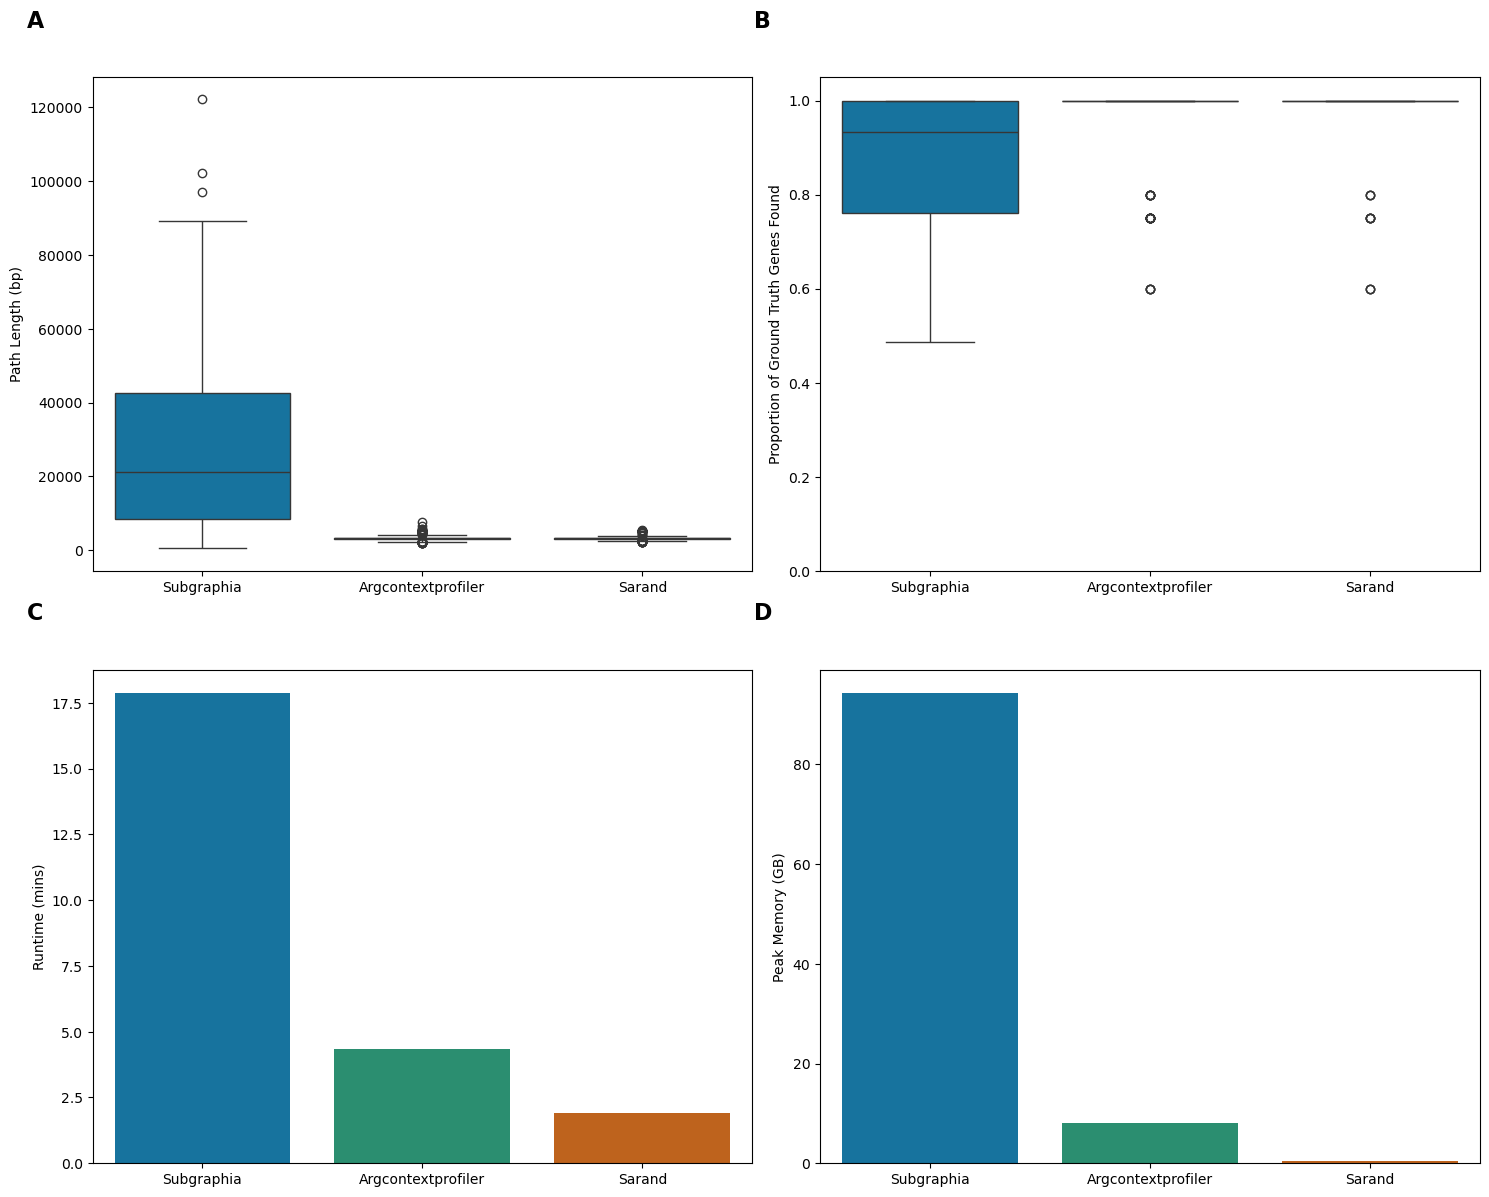

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# benchmarking figures for zymobiomics data

# read in Subgraphia data
## proportion-query-genes-found
fai_subgraphia_zym = pd.read_csv('../fai_correctness/RZ_SR_fai_out.tsv', sep='\t')
fai_subgraphia_zym['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_subgraphia_zym['Tool'] = 'Subgraphia'
## print median proportion-query-genes-found for Subgraphia on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_subgraphia_zym = fai_subgraphia_zym['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Subgraphia on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_subgraphia_zym}")


## length 
subgraphia_zym_summarized = pd.read_csv('../summarized_metadata/zym_SR_summarized.tsv', sep='\t')

# keep only the "length" and "dataset" columns
subgraphia_zym_lengths = subgraphia_zym_summarized[['path_length', 'dataset']]
# rename "path_length" column to "length"
subgraphia_zym_lengths = subgraphia_zym_lengths.rename(columns={'path_length': 'length'})
# print median path length
median_length_subgraphia_zym = subgraphia_zym_lengths['length'].median()
print(f"Median path length for Subgraphia on ZymoBIOMICS Mock Community: {median_length_subgraphia_zym}")

## runtime (mins)
subG_time = 17.87

## memory (GB)

subG_trace = pd.read_csv('subgraphia_RZ_trace.tsv', sep='\t')
peak_RSS_subg = subG_trace['peak_rss'].max() / (1024 * 1024 * 1024)  # convert from bytes to GB
print(f"Peak RSS for SubGraphia: {peak_RSS_subg:.2f} GB")




# read in Argcontextprofiler data
## proportion-query-genes-found
fai_AGCP_zym = pd.read_csv('ARGCP_RZ_fai_out.tsv', sep='\t')
fai_AGCP_zym['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_AGCP_zym['Tool'] = 'Argcontextprofiler'
## print median proportion-query-genes-found for Argcontextprofiler on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_AGCP_zym = fai_AGCP_zym['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Argcontextprofiler on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_AGCP_zym}")

## length
AGCP_lengths = pd.read_csv('ARGCP_RZ_lengths.tsv', sep='\t', header=None, names=['name', 'length'])
AGCP_lengths['dataset'] = 'Argcontextprofiler'
AGCP_lengths = AGCP_lengths[['length', 'dataset']]
# print median path length
median_length_AGCP = AGCP_lengths['length'].median()
print(f"Median path length for Argcontextprofiler on ZymoBIOMICS Mock Community: {median_length_AGCP}")

## runtime (mins)
AGCP_time = 4.332

## memory (GB)
AGCP_mem = 8


# read in Sarand data
## proportion-query-genes-found
fai_sarand_RZ = pd.read_csv('sarand_RZ_SR_fai_out.tsv', sep='\t')
fai_sarand_RZ['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_sarand_RZ['Tool'] = 'Sarand'
# print median proportion-query-genes-found for Sarand on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_sarand_RZ = fai_sarand_RZ['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Sarand on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_sarand_RZ}")

## length
sarand_length_RZ = pd.read_csv('sarand_RZ_lengths.tsv', sep='\t', header=None, names=['name', 'length'])
sarand_length_RZ['dataset'] = 'ZymoBIOMICS Mock Community'
## print median path length
median_length_sarand_RZ = sarand_length_RZ['length'].median()
print(f"Median path length for Sarand on ZymoBIOMICS Mock Community: {median_length_sarand_RZ}")

## runtime (mins)
sar_time = 1.91

## memory (GB)
sar_mem = 0.45

# combine data into query_genes_found_df, length_df, runtime_df, memory_df for plotting

#create list of subgraphia query genes found, argcontextprofiler query genes found, and sarand query genes found
subg_query_genes_found = fai_subgraphia_zym['proportion-query-genes-found']
argconpro_genes_found = fai_AGCP_zym['proportion-query-genes-found']
sarand_genes_found = fai_sarand_RZ['proportion-query-genes-found']
# combine lists to create query_genes_found_df
query_genes_found_df = pd.DataFrame({
    'Subgraphia': subg_query_genes_found,
    'Argcontextprofiler': argconpro_genes_found,
    'Sarand': sarand_genes_found
})


# create lists of subgraphia lengths, argcontextprofiler lengths, and sarand lengths
subg_lengths = subgraphia_zym_lengths['length']
argconpro_lengths = AGCP_lengths['length']
sarand_lengths = sarand_length_RZ['length']
# combine lists to create length_df
length_df = pd.DataFrame({
    'Subgraphia': subg_lengths,
    'Argcontextprofiler': argconpro_lengths,
    'Sarand': sarand_lengths
})

runtime_df = pd.DataFrame({
    'Subgraphia': [subG_time],
    'Argcontextprofiler': [AGCP_time],
    'Sarand': [sar_time]
})

memory_df = pd.DataFrame({
    'Subgraphia': [peak_RSS_subg],
    'Argcontextprofiler': [AGCP_mem],
    'Sarand': [sar_mem]
})

tool_palette = ['#007bb4ff','#1B9E77FF', '#D95F02FF']
# create a four panel figure with proportion-query-genes-found, length, runtime and memory, label with A, B, C, D in the top left corner of each panel, and save as a png
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
# add labels to each panel
axs[0, 0].text(-0.1, 1.1, 'A', transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')
axs[0, 1].text(-0.1, 1.1, 'B', transform=axs[0, 1].transAxes, fontsize=16, fontweight='bold')
axs[1, 0].text(-0.1, 1.1, 'C', transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')
axs[1, 1].text(-0.1, 1.1, 'D', transform=axs[1, 1].transAxes, fontsize=16, fontweight='bold')
sns.boxplot(data=query_genes_found_df, ax=axs[0, 1], palette=tool_palette)
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylim(0, 1.05)
axs[0, 1].set_ylabel('Proportion of Ground Truth Genes Found')
#boxplot for length
sns.boxplot(data=length_df, ax=axs[0, 0], palette=tool_palette)
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Path Length (bp)') 

sns.barplot(data=runtime_df, ax=axs[1, 0], palette=tool_palette)
axs[1, 0].set_xlabel('')
axs[1, 0].set_ylabel('Runtime (mins)')
sns.barplot(data=memory_df, ax=axs[1, 1], palette=tool_palette)
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Peak Memory (GB)')

## save figure
plt.tight_layout()
plt.savefig('../figures_tables/figure_S6.png', dpi=300)